In [7]:

import numpy as np
import logging
logger = logging.getLogger(__name__)
import copy
import h5py
import numpy as np
import matplotlib
import re

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
import matplotlib.animation as animation
from PIL import Image

import os
from os import listdir

In [8]:

# %%
# Parameters
Lx, Lz = 64,1
Nx, Nz = 8192, 128
Ra_M = 1e6
D_0 = 0
D_H = 1/3
M_0 = 0
M_H = -1
N_s2=4/3
Qrad=0.0014

Prandtl = 1
dealias = 3/2


In [9]:

if ( os.path.isfile('./Isentropic_param.py')):
    from MRBC2D_param import *

# %%
expname = 'MRBC_2D_RaM_'+"{:.1e}".format(Ra_M)  +'_Pr_'+"{:.1e}".format(Prandtl) \
    +'_QR_'+"{:.1e}".format(Qrad) \
            +'_DH_'+"{:.1e}".format(D_H) \
            +  '_Lx_'+"{:.1e}".format(Lx) \
            +   '_Nz_'+"{:d}".format(Nz)

folder_dir = "/scratch/zb2113/DedalusData/2D/"+expname+'/analysis'
save_dir= "/home/zb2113/Dedalus-Postanalysis/2D/"+expname

if not os.path.exists(save_dir):
    os.mkdir(save_dir)


In [10]:

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
# print(file_paths)

# %%
#read coordinates
with h5py.File(folder_dir+'/analysis_s1.h5', mode='r') as file:
    print(list(file.keys()))
    scalekeys=list(file['scales'].keys())
    taskkeys=list(file['tasks'].keys())
    print(scalekeys)
    print(taskkeys)
    #automatic read x y zhash: testing feature
    xhash=scalekeys[-2]
    zhash=scalekeys[-1]
    x=file['scales'][xhash]
    z=file['scales'][zhash]
    x=np.array(x)
    z=np.array(z)


['scales', 'tasks']
['constant', 'iteration', 'sim_time', 'timestep', 'wall_time', 'world_time', 'write_number', 'x_hash_8b84e684ac946d7200c357d51eb5fb618b081e51', 'z_hash_d284f597a983ade9304b26b4bf92bfe0a3d1d846']
['C', 'C flux', 'D', 'M', 'T', 'T flux', 'horizontal avg C', 'horizontal avg C flux', 'uz']


In [11]:

# %%
#Implement Isentropic Analysis

file_paths = [os.path.join(folder_dir, file) for file in listdir(folder_dir) if os.path.isfile(os.path.join(folder_dir, file)) and file.endswith('.h5')]
#sort by the number in the file name
file_paths.sort(key=lambda f: int(re.sub('\D', '', f)))
# print(file_paths)


if not os.path.exists(save_dir+'/isentropic'):
    os.mkdir(save_dir+'/isentropic')


In [12]:
M_0 = 0.2
M_H = -1.2
#Preparation of bins and lists
Msize=(M_0-M_H)/100
bin=np.arange(M_H,M_0,Msize)
Mlist=bin+Msize/2
print(Mlist)
timelist=[]
for file in file_paths:
    with h5py.File(file, mode='r') as file:
        st = file['scales/sim_time']
        simtime = np.array(st)
        timelist.append(simtime)
timelist=np.array(timelist)



[-1.193 -1.179 -1.165 -1.151 -1.137 -1.123 -1.109 -1.095 -1.081 -1.067
 -1.053 -1.039 -1.025 -1.011 -0.997 -0.983 -0.969 -0.955 -0.941 -0.927
 -0.913 -0.899 -0.885 -0.871 -0.857 -0.843 -0.829 -0.815 -0.801 -0.787
 -0.773 -0.759 -0.745 -0.731 -0.717 -0.703 -0.689 -0.675 -0.661 -0.647
 -0.633 -0.619 -0.605 -0.591 -0.577 -0.563 -0.549 -0.535 -0.521 -0.507
 -0.493 -0.479 -0.465 -0.451 -0.437 -0.423 -0.409 -0.395 -0.381 -0.367
 -0.353 -0.339 -0.325 -0.311 -0.297 -0.283 -0.269 -0.255 -0.241 -0.227
 -0.213 -0.199 -0.185 -0.171 -0.157 -0.143 -0.129 -0.115 -0.101 -0.087
 -0.073 -0.059 -0.045 -0.031 -0.017 -0.003  0.011  0.025  0.039  0.053
  0.067  0.081  0.095  0.109  0.123  0.137  0.151  0.165  0.179  0.193]


In [13]:

#Grid mesh
M_grid, z_grid=np.meshgrid(Mlist, z)


# Define batch size
batch_size = 10  # Adjust this value as needed

# Calculate number of batches
num_batches = len(file_paths) // batch_size

# Initialize arrays for batch processing
iP_batches = np.zeros((num_batches, Nz, len(Mlist)))
iM_batches = np.zeros((num_batches, Nz, len(Mlist)))
iMass_batches = np.zeros((num_batches, Nz, len(Mlist)))
iCl_batches = np.zeros((num_batches, Nz, len(Mlist)))
iCf_batches = np.zeros((num_batches, Nz, len(Mlist)))
iDf_batches = np.zeros((num_batches, Nz, len(Mlist)))
iCbar_batches = np.zeros((num_batches, Nz))
iCfbar_batches = np.zeros((num_batches, Nz))
iDfbar_batches = np.zeros((num_batches, Nz))
iCcond_batches = np.zeros((num_batches, Nz, len(Mlist)))

# Precompute the bin edges for M
bin_edges = np.linspace(M_H, M_0, num=len(Mlist)+1)

In [14]:
Mp_grid = np.zeros((Nz))
Mn_grid = np.zeros((Nz))
FCp_grid = np.zeros((Nz))
FCn_grid = np.zeros((Nz))

num_batches = 1
batch_start = 5
# Process data in batches
for batch in range(num_batches):

    start_idx = (batch_start + batch) * batch_size
    end_idx = (batch_start + batch + 1) * batch_size
    batch = batch+ batch_start
    
    iP = np.zeros((Nz, len(Mlist), batch_size))
    iM = np.zeros((Nz, len(Mlist), batch_size))
    iMass = np.zeros((Nz, len(Mlist), batch_size))
    iCl = np.zeros((Nz, len(Mlist), batch_size))
    iCf = np.zeros((Nz, len(Mlist), batch_size))
    iDf = np.zeros((Nz, len(Mlist), batch_size))
    iCbar = np.zeros((Nz, batch_size))
    iCfbar = np.zeros((Nz, batch_size))
    
    for file_idx, file_path in enumerate(file_paths[start_idx:end_idx]):
        with h5py.File(file_path, mode='r') as file:
            M = file['tasks']['M'][:] 
            uz = file['tasks']['uz'][:]
            C = file['tasks']['C'][:]
            Cf = file['tasks']['C flux'][:]
            D = file['tasks']['D'][:]
            uz = file['tasks']['uz'][:]
            Cbar = file['tasks']['horizontal avg C'][:]
            Cfbar = file['tasks']['horizontal avg C flux'][:]
            # Dfbar = file['tasks']['horizontal avg D flux'][:]
            simtime = np.array(file['scales/sim_time'])
        
        for t in range(simtime.shape[0]):
            M_t = M[t, :, :]
            uz_t = uz[t, :, :]
            C_t = C[t, :, :]
            Cf_t = Cf[t, :, :]
            Df_t = D[t, :, :]*uz[t,:,:]
            Cbar_t=Cbar[t,:,:]
            Cfbar_t=Cfbar[t,:,:]
            # Dfbar_t=Dfbar[t,:,:]

            M_indices = np.digitize(M_t, bin_edges) - 1

            for z1 in range(Nz):
                iCbar[z1, file_idx] += Cbar_t[0,z1]
                iCfbar[z1, file_idx] += Cfbar_t[0,z1]
                # iDfbar[z1, file_idx] += Dfbar_t[0,z1]
                for x1 in range(Nx):
                    Mindex = int( (M_t[x1,z1] - M_H)//Msize )
                    iP[z1, Mindex, file_idx] += 1/Msize
                    iM[z1, Mindex, file_idx] += M_t[x1, z1]/Msize
                    iMass[z1, Mindex, file_idx] += uz_t[x1, z1]/Msize
                    iCl[z1, Mindex, file_idx] += C_t[x1, z1]/Msize
                    iCf[z1, Mindex, file_idx] += Cf_t[x1, z1]/Msize
                    iDf[z1, Mindex, file_idx] += Df_t[x1, z1]/Msize
                    #Try grid point calculation

                Mp_grid[z1] =  np.sum(uz_t[:, z1] * (uz_t[:, z1]>0),-1)
                Mn_grid[z1] =  np.sum(uz_t[:, z1] * (uz_t[:, z1]<0),-1)

                FCp_grid[z1] = np.sum(Cf_t[:, z1]  * (uz_t[:, z1] >0),-1)
                FCn_grid[z1] = np.sum(Cf_t[:, z1]  * (uz_t[:, z1] <0),-1)
                Cp_grid = FCp_grid / ( 1e-10 + Mp_grid)
                Cn_grid = FCn_grid / ( 1e-10 + Mn_grid)

            #Old Version
            # for z1 in range(Nz):
            #     iCbar[z1, file_idx] += Cbar_t[0,z1]
            #     iCfbar[z1, file_idx] += Cfbar_t[0,z1]
            #     for m1 in range(len(Mlist)):
            #         mask = M_indices[:, z1] == m1
            #         iP[z1, m1, file_idx] += np.sum(mask)/Msize
            #         iM[z1, m1, file_idx] += np.sum(M_t[:, z1] * mask)/Msize
            #         iMass[z1, m1, file_idx] += np.sum(uz_t[:, z1] * mask)/Msize
            #         iCl[z1, m1, file_idx] += np.sum(C_t[:, z1] * mask)/Msize
            #         iCf[z1, m1, file_idx] += np.sum(Cf_t[:, z1] * mask)/Msize
    # Average over the batch
    iP_batches[batch] = np.average(iP, axis=2)/Nx
    iM_batches[batch] = np.average(iM, axis=2)/Nx
    iMass_batches[batch] = np.average(iMass, axis=2)/Nx
    iCl_batches[batch] = np.average(iCl, axis=2)/Nx
    iCf_batches[batch] = np.average(iCf, axis=2)/Nx
    iDf_batches[batch] = np.average(iDf, axis=2)/Nx
    iCbar_batches[batch] = np.average(iCbar, axis=1)
    iCfbar_batches[batch] = np.average(iCfbar, axis=1)
    # iDfbar_batches[batch] = np.average(iDfbar, axis=1)
    iCcond_batches[batch] = iCl_batches[batch]/(iP_batches[batch]+1e-10)

In [15]:
# Plotting time evolution
for batch in range(num_batches):
    batch = batch+ batch_start
    print(batch)
    tiny = 1e-10
    # iClcond = iCl_batches[batch] / (iP_batches[batch] + tiny)
    
    # Calculate isentropic streamfunctions for this batch
    # Psi_Mass = np.zeros((Nz, len(Mlist)))
    # Psi_M = np.zeros((Nz, len(Mlist)))
    # Psi_C = np.zeros((Nz, len(Mlist)))
    # Psi_Ccond = np.zeros((Nz, len(Mlist)))
    Mp = np.zeros((Nz, len(Mlist)))
    Mn = np.zeros((Nz, len(Mlist)))
    Cp = np.zeros((Nz, len(Mlist)))
    Cn = np.zeros((Nz, len(Mlist)))
    
    # for z1 in range(Nz):
    #     Psi_Mass[z1, 0] = iMass_batches[batch, z1, 0]
    #     Psi_M[z1, 0] = iM_batches[batch, z1, 0]
    #     Psi_C[z1, 0] = iCl_batches[batch, z1, 0]
    #     Psi_Ccond[z1, 0] = iClcond[z1, 0]
    #     Mp[z1,0] = np.maximum(iMass_batches[batch, z1, 0], 0)
    #     Mn[z1,0] = np.minimum(iMass_batches[batch, z1, 0], 0)
    #     Cp[z1,0] = np.maximum(np.sign(iMass_batches[batch, z1, 0]), 0)*iCf_batches[batch, z1, 0]
    #     Cn[z1,0] = np.absolute(np.minimum(np.sign(iMass_batches[batch, z1, 0]), 0))*iCf_batches[batch, z1, 0]
    #     for m1 in range(1, len(Mlist)):
    #         Psi_Mass[z1, m1] = Psi_Mass[z1, m1-1] + iMass_batches[batch, z1, m1]
    #         Psi_M[z1, m1] = Psi_M[z1, m1-1] + iM_batches[batch, z1, m1]
    #         Psi_C[z1, m1] = Psi_C[z1, m1-1] + iCl_batches[batch, z1, m1]
    #         Psi_Ccond[z1, m1] = Psi_Ccond[z1, m1-1] + iClcond[z1, m1]
    #         Mp[z1,m1] = Mp[z1,m1-1] + np.maximum(iMass_batches[batch, z1, m1], 0)
    #         Mn[z1,m1] = Mn[z1,m1-1] + np.minimum(iMass_batches[batch, z1, m1], 0)
    #         Cp[z1,m1] = Cp[z1,m1-1] + np.maximum(np.sign(iMass_batches[batch, z1, m1]), 0)*iCf_batches[batch, z1, m1]
    #         Cn[z1,m1] = Cn[z1,m1-1] + np.absolute(np.minimum(np.sign(iMass_batches[batch, z1, m1]), 0))*iCf_batches[batch, z1, m1]
    # Psi_Mass*=Msize
    # Mn*=Msize
    # Mp*=Msize
    # Cn*=Msize
    # Cp*=Msize

    # Mn=Mn[:,-1]
    # Mp=Mp[:,-1]
    # Cp=Cp[:,-1]
    # Cn=Cn[:,-1]
    # Cp = Cp/Mp
    # Cn = Cn/Mn
    # FCp = Cp- Mp*iCbar_batches[batch]
    # FCn = Cn- Mn*iCbar_batches[batch]

    Mp =  np.sum(iMass_batches[batch, :, :] * (iMass_batches[batch, :,:]>0),-1) * Msize
    Mn =  np.sum(iMass_batches[batch, :, :] * (iMass_batches[batch, :,:]<0),-1) * Msize

    
    FCvp = np.sum(iCcond_batches[batch, :, :] * (iMass_batches[batch, :,:]>0),-1) * Msize
    FCvn = np.sum(iCcond_batches[batch, :, :] * (iMass_batches[batch, :,:]<0),-1) * Msize   
    FCp = np.sum(iCf_batches[batch, :, :] * (iMass_batches[batch, :,:]>0),-1) * Msize
    FCn = np.sum(iCf_batches[batch, :, :] * (iMass_batches[batch, :,:]<0),-1) * Msize
    Cp = FCp / ( 1e-10 + Mp)
    Cn = FCn / ( 1e-10 + Mn)
    Cvp = FCvp / ( 1e-10 + Mp)
    Cvn = FCvn / ( -1e-10 - Mn)

    
    

    if np.any(Mp < 0):
        print(f"Negative Mp found in batch {batch}")
        print("Indices of negative values:", np.where(Mp < 0))
        print("Minimum value:", np.min(Mp))

5


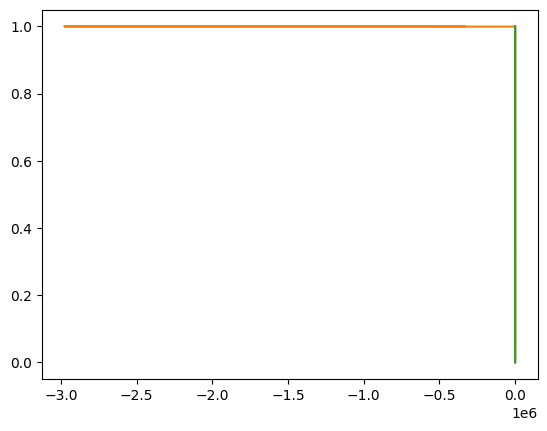

In [16]:
plt.plot(Cp,z)
plt.plot(Cn,z)
plt.plot(iCbar_batches[batch],z)

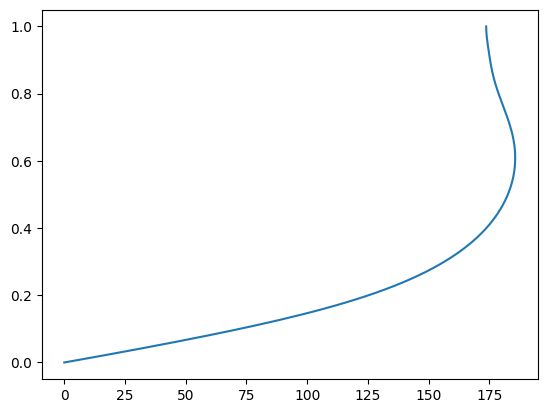

In [17]:
plt.plot(iCbar_batches[batch],z)

In [18]:
iCbar_batches.shape

(20, 128)

In [19]:
# #OP version

# # Plotting time evolution
# for batch in range(num_batches):
#     batch = batch+ batch_start
#     print(batch)
#     tiny = 1e-10
#     iClcond = iCl_batches[batch] / (iP_batches[batch] + tiny)
    
#     # Calculate isentropic streamfunctions for this batch
#     Psi_Mass = np.zeros((Nz, len(Mlist)))
#     Psi_M = np.zeros((Nz, len(Mlist)))
#     Psi_C = np.zeros((Nz, len(Mlist)))
#     Psi_Ccond = np.zeros((Nz, len(Mlist)))
#     Mp = np.zeros((Nz, len(Mlist)))
#     Mn = np.zeros((Nz, len(Mlist)))
#     Cp = np.zeros((Nz, len(Mlist)))
#     Cn = np.zeros((Nz, len(Mlist)))
    
#     for z1 in range(Nz):
#         Psi_Mass[z1, 0] = iMass_batches[batch, z1, 0]
#         Psi_M[z1, 0] = iM_batches[batch, z1, 0]
#         Psi_C[z1, 0] = iCl_batches[batch, z1, 0]
#         Psi_Ccond[z1, 0] = iClcond[z1, 0]
#         Mp[z1,0] = np.maximum(iMass_batches[batch, z1, 0], 0)
#         Mn[z1,0] = np.minimum(iMass_batches[batch, z1, 0], 0)
#         Cp[z1,0] = np.maximum(np.sign(iMass_batches[batch, z1, 0]), 0)*iCf_batches[batch, z1, 0]
#         Cn[z1,0] = np.absolute(np.minimum(np.sign(iMass_batches[batch, z1, 0]), 0))*iCf_batches[batch, z1, 0]
#         for m1 in range(1, len(Mlist)):
#             Psi_Mass[z1, m1] = Psi_Mass[z1, m1-1] + iMass_batches[batch, z1, m1]
#             Psi_M[z1, m1] = Psi_M[z1, m1-1] + iM_batches[batch, z1, m1]
#             Psi_C[z1, m1] = Psi_C[z1, m1-1] + iCl_batches[batch, z1, m1]
#             Psi_Ccond[z1, m1] = Psi_Ccond[z1, m1-1] + iClcond[z1, m1]
#             Mp[z1,m1] = Mp[z1,m1-1] + np.maximum(iMass_batches[batch, z1, m1], 0)
#             Mn[z1,m1] = Mn[z1,m1-1] + np.minimum(iMass_batches[batch, z1, m1], 0)
#             Cp[z1,m1] = Cp[z1,m1-1] + np.maximum(np.sign(iMass_batches[batch, z1, m1]), 0)*iCf_batches[batch, z1, m1]
#             Cn[z1,m1] = Cn[z1,m1-1] + np.absolute(np.minimum(np.sign(iMass_batches[batch, z1, m1]), 0))*iCf_batches[batch, z1, m1]
#     Psi_Mass*=Msize
#     Mn*=Msize
#     Mp*=Msize
#     Cn*=Msize
#     Cp*=Msize

#     Mn=Mn[:,-1]
#     Mp=Mp[:,-1]
#     Cp=Cp[:,-1]
#     Cn=Cn[:,-1]
#     # Cp = Cp/Mp
#     # Cn = Cn/Mn
#     FCp = Cp- Mp*iCbar_batches[batch]
#     FCn = Cn- Mn*iCbar_batches[batch]

#     Mp_op =  np.sum(iMass_batches[batch, :, :] * (iMass_batches[batch, :,:]>0),-1) * Msize
#     Mn_op =  np.sum(iMass_batches[batch, :, :] * (iMass_batches[batch, :,:]<0),-1) * Msize

#     FCp_op = np.sum(iCf_batches[batch, :, :] * (iMass_batches[batch, :,:]>0),-1) * Msize
#     FCn_op = np.sum(iCf_batches[batch, :, :] * (iMass_batches[batch, :,:]<0),-1) * Msize
#     Cp_op = FCp_op / ( 1e-10 + Mp)
#     Cn_op = FCn_op / ( 1e-10 + Mn)

    
    

#     if np.any(Mp < 0):
#         print(f"Negative Mp found in batch {batch}")
#         print("Indices of negative values:", np.where(Mp < 0))
#         print("Minimum value:", np.min(Mp))

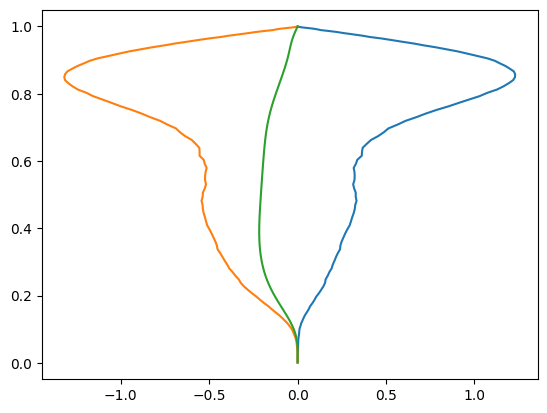

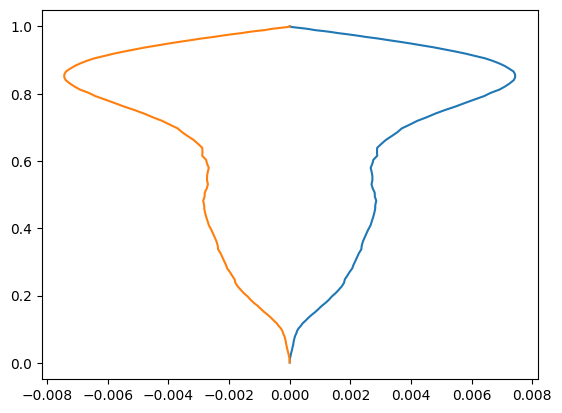

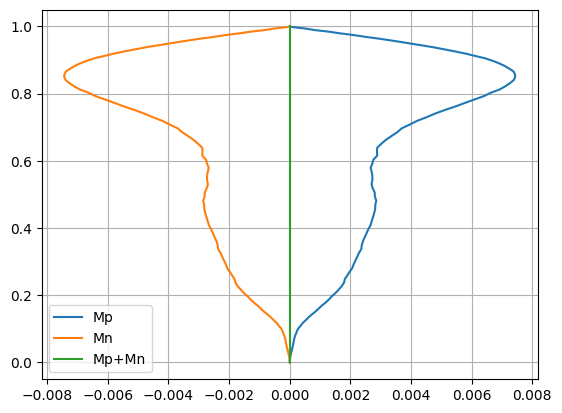

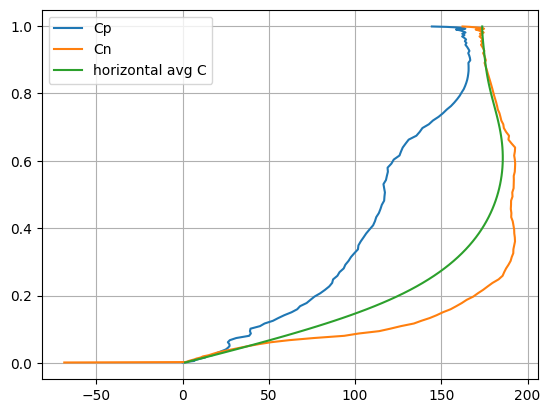

In [20]:
plt.plot(FCp[2:],z[2:])
plt.plot(FCn[2:],z[2:])
plt.plot((FCp+ FCn)[2:],z[2:])
plt.show()
plt.plot(Mp[2:],z[2:])
plt.plot(Mn[2:],z[2:])

plt.show()
plt.plot(Mp,z,label='Mp')
plt.plot(Mn,z,label='Mn')
plt.plot(Mp+Mn,z,label='Mp+Mn')
plt.grid()
plt.legend()
plt.show()
         
plt.plot(Cp[3:-3],z[3:-3],label="Cp")
plt.plot(Cn[3:-3],z[3:-3],label="Cn")
# plt.plot(np.mean(C,(0,1)),z)
plt.plot(iCbar_batches[batch][3:-3],z[3:-3],label="horizontal avg C")
plt.grid()
plt.legend()

# plt.xlim(0,400)

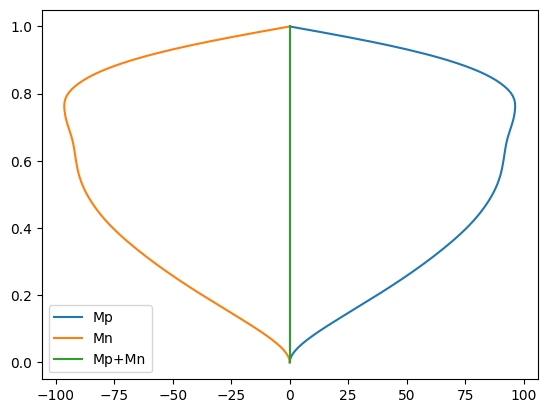

In [21]:
plt.plot(Mp_grid,z,label='Mp')
plt.plot(Mn_grid,z,label='Mn')
plt.plot(Mp_grid+Mn_grid,z,label='Mp+Mn')
plt.legend()
plt.show()

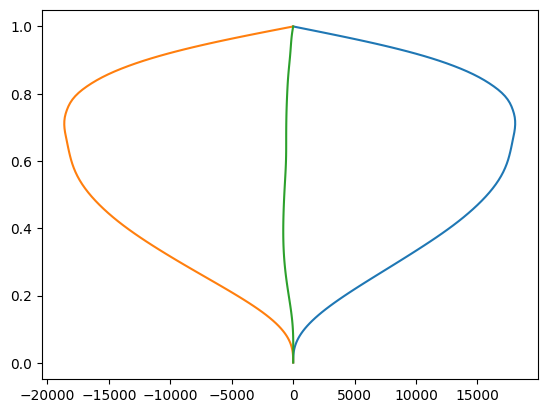

In [22]:
plt.plot(FCp_grid[2:],z[2:])
plt.plot(FCn_grid[2:],z[2:])
plt.plot((FCp_grid+ FCn_grid)[2:],z[2:])
plt.show()

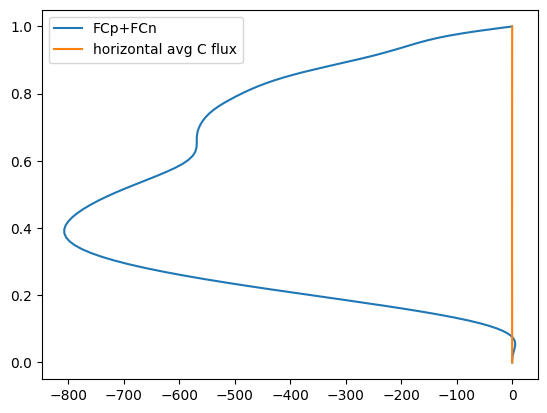

In [23]:
plt.plot((FCp_grid+ FCn_grid),z, label="FCp+FCn")
plt.plot(iCfbar_batches[batch],z,label="horizontal avg C flux")
plt.legend()

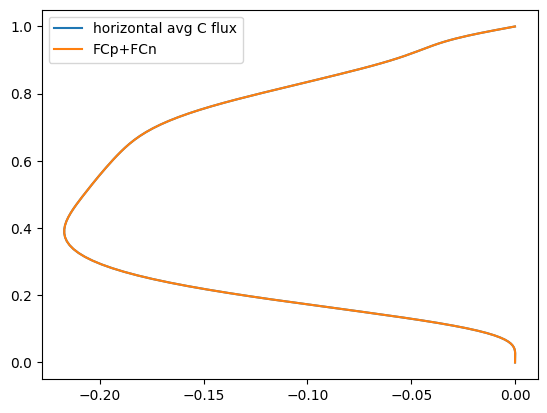

In [24]:
plt.plot(iCfbar_batches[batch],z,label="horizontal avg C flux")
plt.plot((FCp+ FCn),z, label="FCp+FCn")
plt.legend()


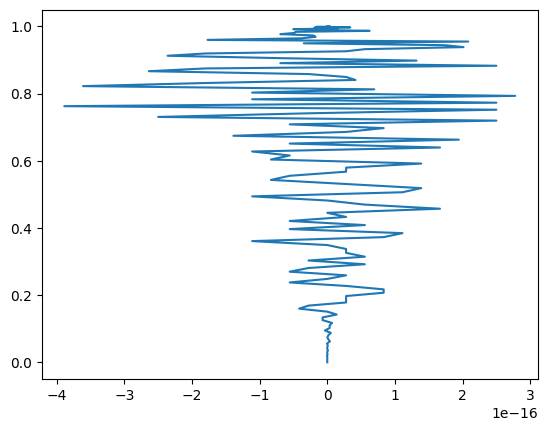

In [25]:
plt.plot((FCp+ FCn-iCfbar_batches[batch]),z)

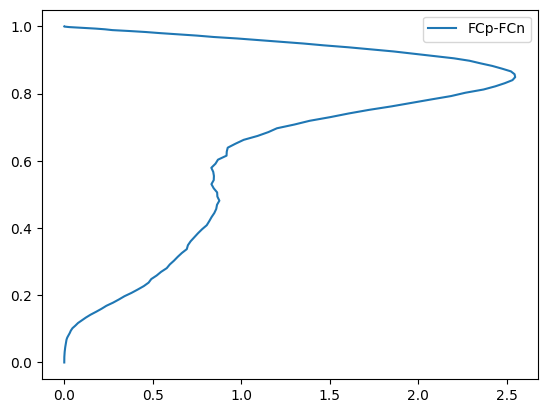

In [26]:
plt.plot(FCp-FCn,z, label="FCp-FCn")
plt.legend()

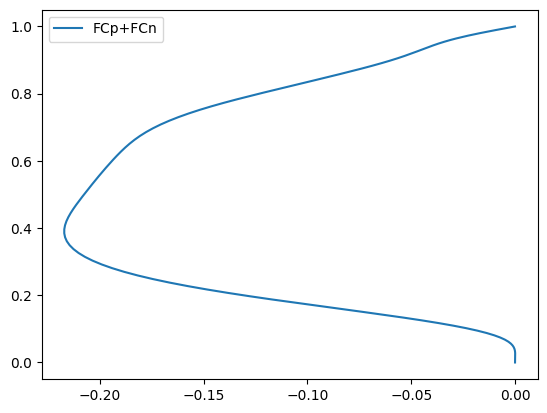

In [27]:
plt.plot(FCp+FCn,z, label="FCp+FCn")
# plt.plot((FCp-Mp*iCbar_batches[batch]+FCn-Mn*iCbar_batches[batch]),z, label="FCp+FCn 2")
plt.legend()

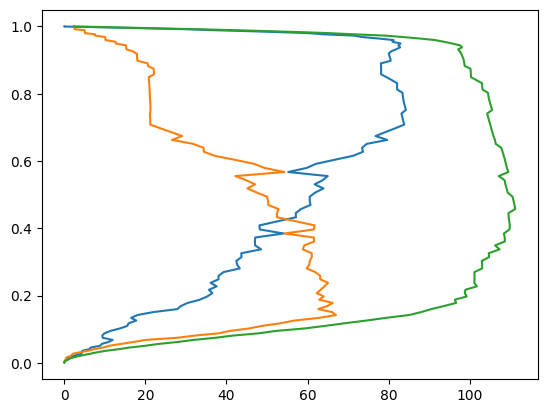

In [28]:
plt.plot(FCvp[2:],z[2:])
plt.plot(FCvn[2:],z[2:])
plt.plot((FCvp+ FCvn)[2:],z[2:])
plt.show()

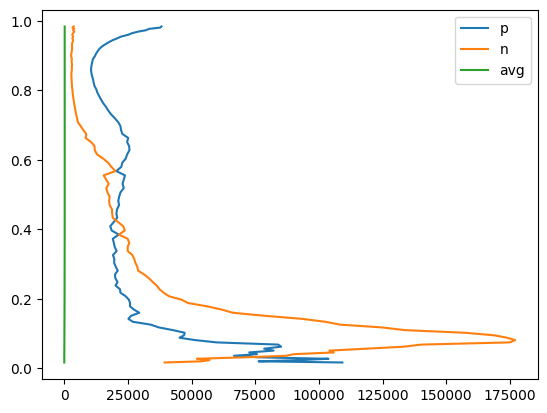

In [29]:
plt.plot(Cvp[10:-10],z[10:-10],label='p')
plt.plot(Cvn[10:-10],z[10:-10],label='n')
plt.plot(iCbar_batches[batch][10:-10],z[10:-10],label='avg')
plt.legend()
plt.show()